# Experiments for Paper Materials

Ноутбук запускает 5 сценариев из плана статьи, считает RecSys- и matching-метрики, сохраняет CSV, графики и кейсы в `paper_materials/`.


In [1]:
import os
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'paper_materials' else Path.cwd()
SRC_DIR = PROJECT_ROOT / 'src'
sys.path.insert(0, str(SRC_DIR))
sys.path.insert(0, str(PROJECT_ROOT / 'paper_materials'))
os.environ.setdefault('DJANGO_SETTINGS_MODULE', 'config.settings')
os.environ["DJANGO_ALLOW_ASYNC_UNSAFE"] = "true"
os.environ['POSTGRES_HOST'] = 'localhost'
os.environ['POSTGRES_PORT'] = '5433'  # проброс из docker-compose: 5433:5432

import django
django.setup()

%matplotlib inline

from utils import ExperimentConfig, load_django_dataset, parse_ground_truth_json, save_all_artifacts, save_ground_truth_prompt, show_experiment_plots

## Ground Truth через внешний LLM

1. Выполните следующую ячейку и скопируйте `prompt` в браузерный чат LLM.
2. Вставьте JSON-ответ в переменную `LLM_GT_RESPONSE`.
3. Если ответ пустой, notebook использует воспроизводимый proxy ground truth из скрытой синтетической близости профилей и проектов.

In [2]:
config = ExperimentConfig(students_limit=150, projects_limit=100, top_k=5, seed=42)
students, projects = load_django_dataset(config)
prompt_path = PROJECT_ROOT / 'paper_materials' / 'ground_truth_prompt.txt'
save_ground_truth_prompt(prompt_path, students, projects, limit=150)
print(f'Промпт: {prompt_path} ({prompt_path.stat().st_size} байт)')
print(prompt_path.read_text(encoding='utf-8')[:1200], '...\n[полный текст в файле]')

Промпт: /Users/user/Desktop/Учеба/cursach/2025_hse_dsa/paper_materials/ground_truth_prompt.txt (266532 байт)
Подбери идеальный проект для каждого студента по смысловому соответствию профиля и проекта.
Верни строго JSON-массив без markdown, ровно для student_id: 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150.
[{"student_id": <int>, "ideal_project_id": <int>, "reason": "<коротко>"}]

Студенты:
- student_i

In [3]:
LLM_GT_RESPONSE = (PROJECT_ROOT / 'paper_materials' / 'ground_truth_result.txt').read_text(encoding='utf-8')

ground_truth = parse_ground_truth_json(LLM_GT_RESPONSE) if LLM_GT_RESPONSE.strip() else None
ground_truth

{1: 107,
 2: 13,
 3: 2,
 4: 62,
 5: 11,
 6: 87,
 7: 107,
 8: 11,
 9: 37,
 10: 170,
 11: 6,
 12: 138,
 13: 135,
 14: 157,
 15: 44,
 16: 42,
 17: 107,
 18: 97,
 19: 11,
 20: 68,
 21: 89,
 22: 62,
 23: 11,
 24: 108,
 25: 44,
 26: 107,
 27: 171,
 28: 62,
 29: 138,
 30: 138,
 31: 113,
 32: 47,
 33: 11,
 34: 181,
 35: 204,
 36: 170,
 37: 18,
 38: 68,
 39: 2,
 40: 11,
 41: 91,
 42: 33,
 43: 89,
 44: 89,
 45: 150,
 46: 157,
 47: 143,
 48: 138,
 49: 170,
 50: 150,
 51: 62,
 52: 89,
 53: 188,
 54: 11,
 55: 19,
 56: 11,
 57: 170,
 58: 170,
 59: 19,
 60: 138,
 61: 170,
 62: 68,
 63: 62,
 64: 11,
 65: 171,
 66: 62,
 67: 171,
 68: 2,
 69: 170,
 70: 89,
 71: 138,
 72: 2,
 73: 11,
 74: 42,
 75: 62,
 76: 170,
 77: 138,
 78: 170,
 79: 157,
 80: 19,
 81: 62,
 82: 11,
 83: 2,
 84: 11,
 85: 204,
 86: 11,
 87: 107,
 88: 19,
 89: 62,
 90: 138,
 91: 157,
 92: 11,
 93: 165,
 94: 11,
 95: 11,
 96: 170,
 97: 11,
 98: 11,
 99: 89,
 100: 107,
 101: 107,
 102: 37,
 103: 62,
 104: 89,
 105: 170,
 106: 138,
 107: 100

## Запуск 5 сценариев

Сценарии: Base, RecSys-only, RecSys + Prof. Rank, Hybrid, Stable Matching.

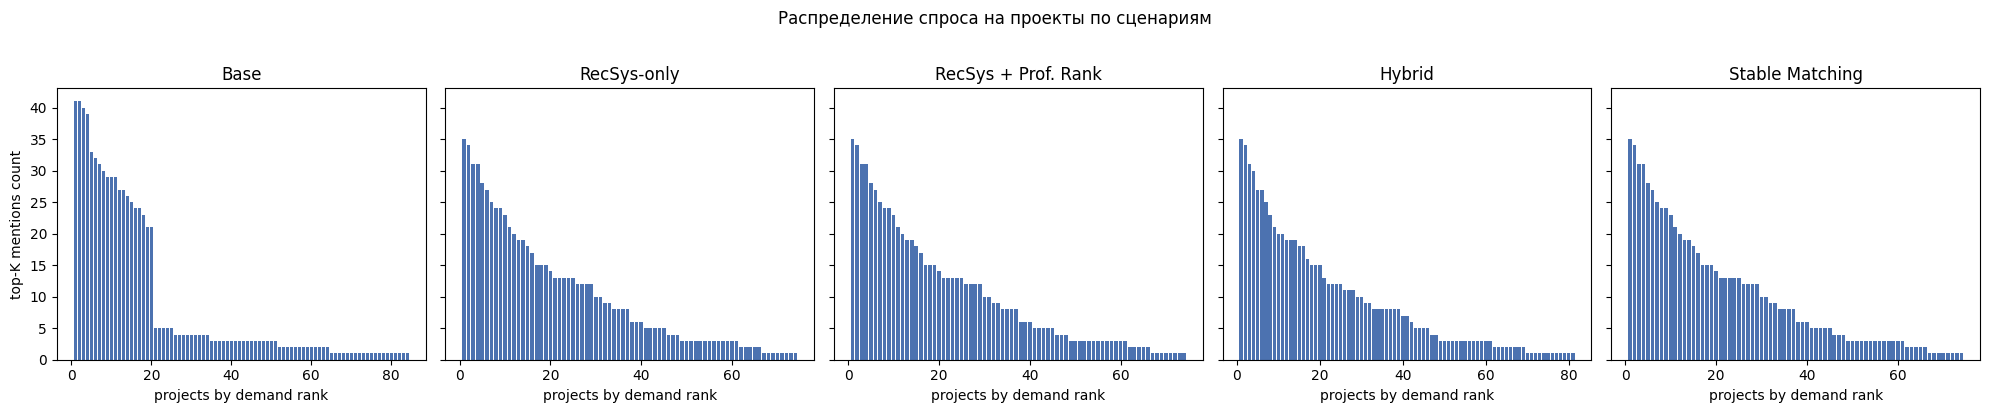

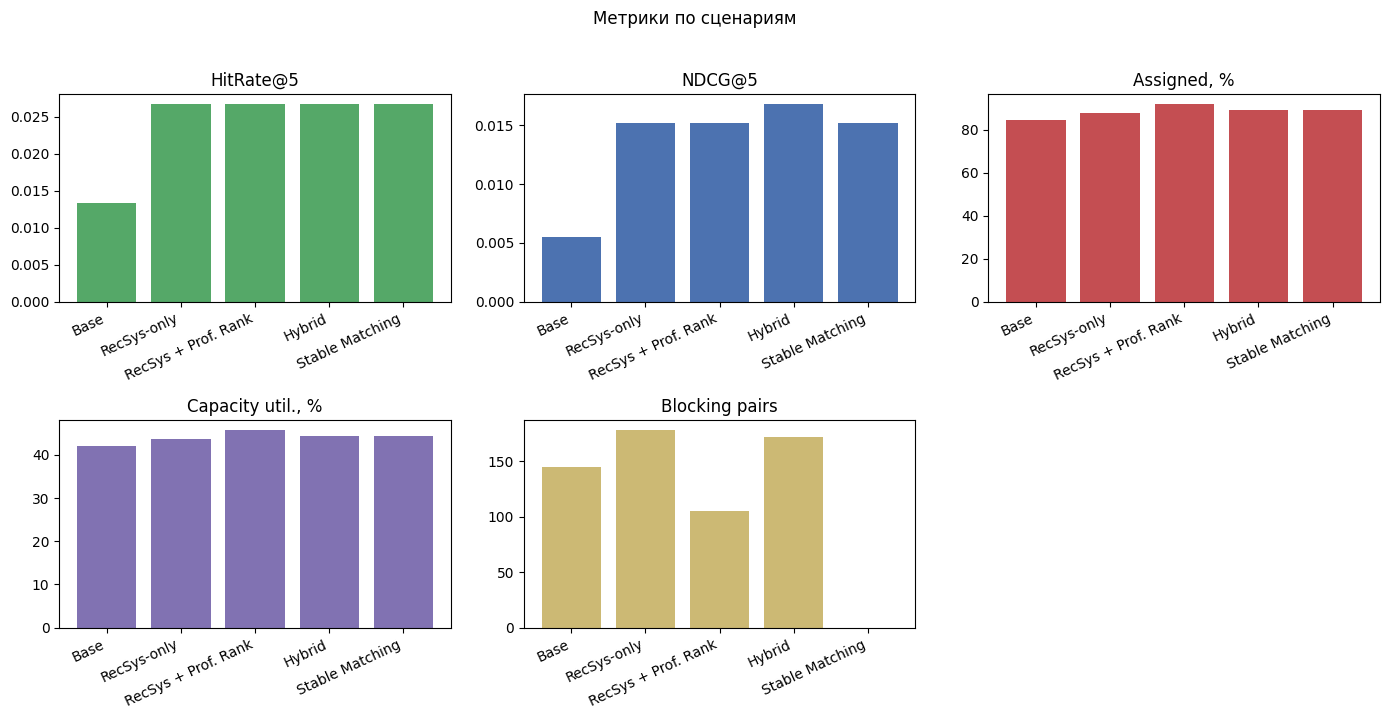

[{'scenario_id': 'base',
  'scenario_name': 'Base',
  'hit_rate_at_5': 0.0133,
  'ndcg_at_5': 0.0055,
  'assigned_pct': 84.67,
  'capacity_utilization_pct': 42.05,
  'blocking_pairs': 145},
 {'scenario_id': 'recsys_only',
  'scenario_name': 'RecSys-only',
  'hit_rate_at_5': 0.0267,
  'ndcg_at_5': 0.0152,
  'assigned_pct': 88.0,
  'capacity_utilization_pct': 43.71,
  'blocking_pairs': 178},
 {'scenario_id': 'recsys_prof_rank',
  'scenario_name': 'RecSys + Prof. Rank',
  'hit_rate_at_5': 0.0267,
  'ndcg_at_5': 0.0152,
  'assigned_pct': 92.0,
  'capacity_utilization_pct': 45.7,
  'blocking_pairs': 105},
 {'scenario_id': 'hybrid',
  'scenario_name': 'Hybrid',
  'hit_rate_at_5': 0.0267,
  'ndcg_at_5': 0.0168,
  'assigned_pct': 89.33,
  'capacity_utilization_pct': 44.37,
  'blocking_pairs': 172},
 {'scenario_id': 'stable_matching',
  'scenario_name': 'Stable Matching',
  'hit_rate_at_5': 0.0267,
  'ndcg_at_5': 0.0152,
  'assigned_pct': 89.33,
  'capacity_utilization_pct': 44.37,
  'blocking_

In [4]:
materials_dir = PROJECT_ROOT / 'paper_materials'
metrics, demand_histograms = save_all_artifacts(
    materials_dir,
    config=config,
    ground_truth=ground_truth,
    show_plots=True,
)
metrics

In [5]:
import pandas as pd
display(pd.read_csv(materials_dir / 'results_table.csv'))

,scenario_id,scenario_name,hit_rate_at_5,ndcg_at_5,assigned_pct,capacity_utilization_pct,blocking_pairs
0,base,Base,0.0133,0.0055,84.67,42.05,145
1,recsys_only,RecSys-only,0.0267,0.0152,88.00,43.71,178
2,recsys_prof_rank,RecSys + Prof. Rank,0.0267,0.0152,92.00,45.70,105
3,hybrid,Hybrid,0.0267,0.0168,89.33,44.37,172
4,stable_matching,Stable Matching,0.0267,0.0152,89.33,44.37,0
